# Retreino acumulativo após a mudança de conceito — equipamento B-8802B

**Pergunta:** depois de detectar a mudança de conceito, dá para colocar um modelo novo em produção
com 1 mês de dados, em vez de esperar 12? E como fica a série de alarmes ao longo do caminho?

**O esquema testado** (código em `src/transpetro_modelos/drift/acumulativo.py`)
- **jan/2025 — quarentena:** a mudança é detectada nos primeiros dias de janeiro. O modelo antigo segue
  rodando (com os alarmes tratados com ressalva) enquanto o mês de dado novo é coletado.
- **Etapa k (k = 1 a 12):** um modelo treinado com os k primeiros meses de 2025 opera durante o mês seguinte.
  A cada mês ele é retreinado com tudo o que acumulou.
- **A partir de jan/2026:** o modelo com 12 meses fica fixo.

Mesma receita do modelo em produção: VAE com a arquitetura aprovada no retreino, limiar média + 6,5 desvios
do erro na janela de treino, persistência de 15 em 20 leituras.

**O que é medido em cada etapa**, sempre no mês em que aquele modelo estaria em produção:
alarme % (candidatos a falso positivo), falha sintética injetada naquele mês (100 % e 50 % da assinatura
real de 2022) e a falha real de 2022, que nenhuma etapa viu.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists(): PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from transpetro_modelos.drift import acumulativo as ac

SAIDA = PROJECT_ROOT / "results/acumulativo_b8802b"          # modelos em cache: reexecutar é rápido
res = ac.rodar(SAIDA, n_meses=12, epochs=60, log=lambda m: None)
print(f"{len(res)} etapas")

12 etapas


## A curva de maturação

In [2]:
tab = pd.DataFrame({
    "meses de treino": res["meses_de_treino"],
    "opera em": res["vivo_ini"].dt.strftime("%m/%Y") + np.where(res["etapa"] == res["etapa"].max(), " em diante", ""),
    "alarme no mês (%)": res["alarme_pct_vivo"].round(3),
    "falha sintética 100 % (h antes)": res["sintetica_100_h"].round(0),
    "falha sintética 50 % (h antes)": res["sintetica_50_h"].round(0),
    "falha real 2022 (dias antes)": res["falha_2022_dias"].round(2),
    "alarme no normal de 2022 (%)": res["normal_2022_pct"].round(2),
}).set_index("meses de treino")
tab

,opera em,alarme no mês (%),falha sintética 100 % (h antes),falha sintética 50 % (h antes),falha real 2022 (dias antes),alarme no normal de 2022 (%)
meses de treino,,,,,,
1,02/2025,0.000,17.0,NaN,2.09,1.79
2,03/2025,0.617,31.0,-15.0,1.82,3.00
3,04/2025,0.000,11.0,12.0,1.94,0.00
4,05/2025,0.000,-10.0,NaN,2.00,1.52
5,06/2025,0.000,NaN,NaN,1.74,0.00
6,07/2025,0.000,0.0,NaN,NaN,0.00
7,08/2025,0.000,NaN,NaN,2.12,0.00
8,09/2025,0.000,3.0,NaN,2.12,2.59
9,10/2025,0.000,2.0,NaN,1.93,2.50


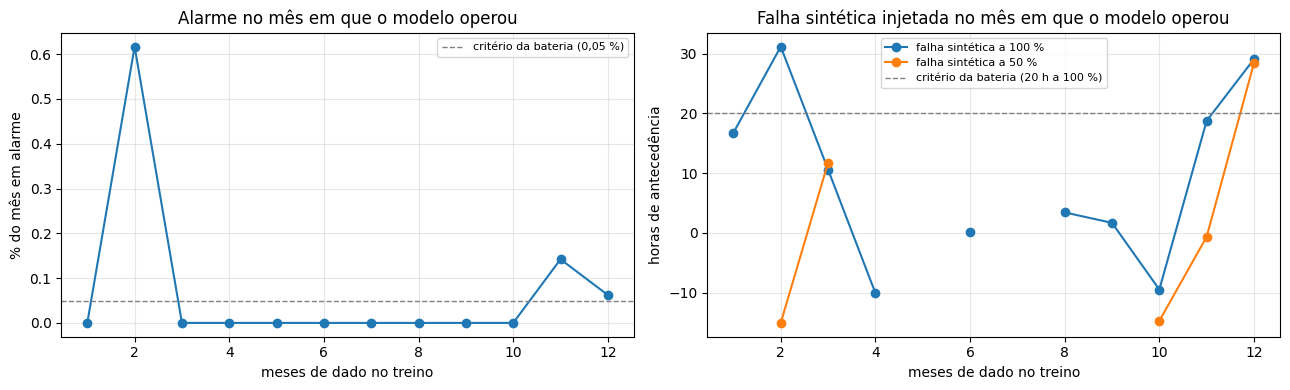

etapas sem valor na sintética = falha não detectada (ou mês sem janela de 72 h de operação para injetar)


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(res["meses_de_treino"], res["alarme_pct_vivo"], marker="o")
ax[0].axhline(0.05, color="gray", linestyle="--", linewidth=1, label="critério da bateria (0,05 %)")
ax[0].set_xlabel("meses de dado no treino"); ax[0].set_ylabel("% do mês em alarme"); ax[0].set_title("Alarme no mês em que o modelo operou")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
ax[1].plot(res["meses_de_treino"], res["sintetica_100_h"], marker="o", label="falha sintética a 100 %")
ax[1].plot(res["meses_de_treino"], res["sintetica_50_h"], marker="o", label="falha sintética a 50 %")
ax[1].axhline(20, color="gray", linestyle="--", linewidth=1, label="critério da bateria (20 h a 100 %)")
ax[1].set_xlabel("meses de dado no treino"); ax[1].set_ylabel("horas de antecedência"); ax[1].set_title("Falha sintética injetada no mês em que o modelo operou")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("etapas sem valor na sintética = falha não detectada (ou mês sem janela de 72 h de operação para injetar)")

### A mesma falha sintética, na mesma data, para todas as etapas

No gráfico acima cada etapa recebeu a falha num mês diferente (o mês em que operou), então parte da variação pode
vir do mês e não do modelo. Aqui todas as etapas recebem a falha na mesma data (10/06/2026, a mesma usada na
bateria de validação). Valor negativo = alarme depois do fim da rampa; vazio = não detectou.

In [4]:
csv_fixa = SAIDA / "sintetica_data_fixa.csv"
fixa = pd.read_csv(csv_fixa) if csv_fixa.exists() else ac.sintetica_data_fixa(SAIDA)
fixa.round(1).rename(columns={"sintetica_fixa_100_h": "falha sintética 100 % (h antes)",
                              "sintetica_fixa_50_h": "falha sintética 50 % (h antes)"}).set_index("etapa")

,falha sintética 100 % (h antes),falha sintética 50 % (h antes)
etapa,,
1,NaN,NaN
2,NaN,-2.9
3,-19.7,-2.9
4,NaN,NaN
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,-21.4,NaN
9,NaN,NaN


## A série completa: o que o sistema teria alarmado

Emendando, mês a mês, o modelo que estaria em produção em cada momento. Em jan/2025 (quarentena) aparece o
modelo antigo. A curva é o erro de reconstrução dividido pelo limiar do modelo vigente (acima de 1 = acima
do limiar; o alarme exige 15 de 20 leituras acima).

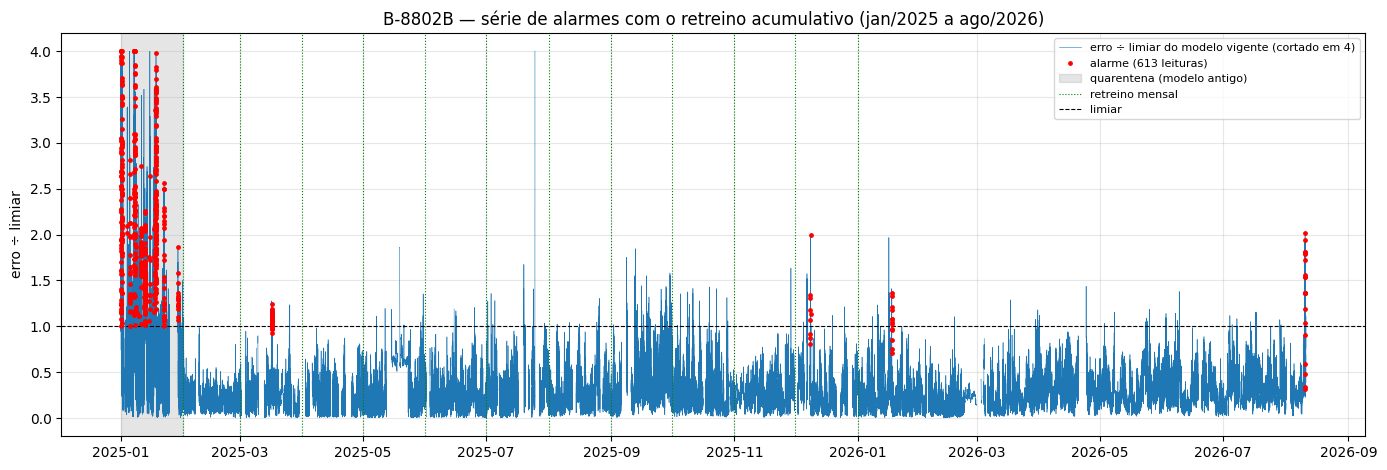

fora da quarentena: 0.063 % do tempo em alarme (83 leituras)


In [5]:
DEP = PROJECT_ROOT / "deploy_v2/Transpetro"
thr_antigo = json.loads((DEP / "B-8802B/modelos/model_2022-05-15_2022-07-21_VAE/alarm.json").read_text())["threshold"]
antigo = pd.read_csv(PROJECT_ROOT / "results/monitor_drift/b8802b_modelo2022_em_2025-26_inferencia.csv", index_col=0, parse_dates=True)
quarentena = antigo.loc[:"2025-01-31"].rename(columns={"reconstruction_error": "erro", "is_anomaly": "alarme"})[["erro", "alarme"]]
quarentena["limiar"] = thr_antigo
serie = ac.serie_emendada(SAIDA, quarentena)
razao = (serie["erro"] / serie["limiar"]).clip(upper=4)
buraco = serie.index.to_series().diff() > pd.Timedelta(hours=6)
r_plot = pd.concat([razao, pd.Series(np.nan, index=serie.index[buraco] - pd.Timedelta(seconds=1))]).sort_index()
al = serie[serie["alarme"]]
plt.figure(figsize=(14, 4.8))
plt.plot(r_plot.index, r_plot.values, linewidth=0.4, label="erro ÷ limiar do modelo vigente (cortado em 4)")
plt.scatter(al.index, (al["erro"] / al["limiar"]).clip(upper=4), s=6, color="red", zorder=3, label=f"alarme ({len(al)} leituras)")
plt.axvspan(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-02-01"), color="gray", alpha=0.2, label="quarentena (modelo antigo)")
for i, t in enumerate(res["vivo_ini"]):
    plt.axvline(t, color="green", linestyle=":", linewidth=0.8, label="retreino mensal" if i == 0 else None)
plt.axhline(1, color="black", linestyle="--", linewidth=0.8, label="limiar")
plt.ylabel("erro ÷ limiar"); plt.title("B-8802B — série de alarmes com o retreino acumulativo (jan/2025 a ago/2026)")
plt.legend(loc="upper right", fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
fora = serie[serie["etapa"] > 0]
print(f"fora da quarentena: {100 * fora['alarme'].mean():.3f} % do tempo em alarme ({int(fora['alarme'].sum())} leituras)")

## Episódios de alarme (fora da quarentena)

Cada episódio é um bloco de alarmes separado do seguinte por mais de 12 h. O sensor principal é o que mais
contribuiu para o erro de reconstrução no episódio. A coluna "conhecido" marca os episódios de 2025–26 que já
têm justificativa técnica (`docs/justificativa_alarmes_b8802b_2025.md`).

In [6]:
CONHECIDOS = {"ep1 06/12/25 (térmico)": ("2025-12-06 22:45", "2025-12-07 01:20"),
              "ep2 17/01/26 (vibração LA+LNA)": ("2026-01-17 21:30", "2026-01-17 22:40"),
              "ep3 24/07/26 (operacional)": ("2026-07-24 14:35", "2026-07-24 14:55"),
              "ep4 10/08/26 (sucção/vibração)": ("2026-08-10 12:45", "2026-08-10 16:25")}
ep = ac.episodios(serie, SAIDA)
def conhecido(row):
    for nome, (a, b) in CONHECIDOS.items():
        if row["inicio"] <= pd.Timestamp(b) + pd.Timedelta(hours=12) and row["fim"] >= pd.Timestamp(a) - pd.Timedelta(hours=12):
            return nome
    return ""
ep["conhecido"] = ep.apply(conhecido, axis=1)
ep["meses de treino do modelo"] = ep["etapa"]
ep_tab = ep.assign(inicio=ep["inicio"].dt.strftime("%d/%m/%Y %H:%M"), fim=ep["fim"].dt.strftime("%d/%m/%Y %H:%M"))
ep_tab[["inicio", "fim", "duracao_h", "meses de treino do modelo", "erro_max_x_limiar", "sensor_principal", "peso_sensor_principal_pct", "conhecido"]]

,inicio,fim,duracao_h,meses de treino do modelo,erro_max_x_limiar,sensor_principal,peso_sensor_principal_pct,conhecido
0,16/03/2025 19:10,16/03/2025 22:20,3.2,2,1.24,Pressão Descarga,55.0,
1,08/12/2025 14:30,08/12/2025 17:00,2.6,11,2.00,Pressão Descarga,64.0,
2,17/01/2026 21:40,17/01/2026 22:40,1.1,12,1.36,Vibração Bomba LA,38.0,ep2 17/01/26 (vibração LA+LNA)
3,10/08/2026 12:55,10/08/2026 16:30,3.7,12,2.01,Temperatura Bomba LA,31.0,ep4 10/08/26 (sucção/vibração)


## Leitura

**1. Falso positivo: o esquema acumulativo funciona desde o 1º mês.** Fora da quarentena, o sistema fica
0,063 % do tempo em alarme, com 4 episódios em 19 meses. O modelo de 1 mês, em fevereiro/2025, não deu
nenhum alarme. O modelo antigo, no mesmo período, ficava 12,2 % do tempo em alarme.

**2. Sensibilidade: um treino único não é confiável.** Com a falha sintética injetada na mesma data para
todas as etapas, os modelos de 1 a 9 meses quase nunca a detectam, e o de 12 meses pegou só 7 h antes. O
modelo aprovado pelo pipeline de retreino (mesma arquitetura, mesmos 12 meses) pegou 22 h antes na mesma data.
A diferença é a inicialização aleatória do treino. Aqui cada etapa treinou **um** modelo, sem a seleção
entre candidatos e a bateria que o pipeline de retreino faz. Conclusão: cada etapa do esquema acumulativo
precisa do mesmo mecanismo (vários candidatos + bateria), senão o modelo provisório pode sair cego.

**3. Os episódios de alarme**

| episódio | modelo | leitura |
|---|---|---|
| 17/01/2026 e 10/08/2026 | 12 meses | episódios reais, já justificados (ep2 e ep4) |
| 16/03/2025, 3,2 h | 2 meses | pressão de descarga em 56,1 bar, no limite do que o modelo tinha visto (p99 de jan–fev: 56,2) → **candidato a falso positivo** do modelo jovem |
| 08/12/2025, 2,6 h | 11 meses | pressão de descarga em 57,8 bar, acima do p99 do ano (56,4), com degrau de sucção (3,9 → 5,1 bar) e aumento da vibração LA → ponto de operação fora da faixa de treino; **candidato a falso positivo** (ou a verificar com a operação) |

Os dois candidatos têm a **pressão de descarga** como sensor principal (55 % e 64 % do erro). A pressão
constante por horas não é o motivo: em 80 % do tempo de 2025 ela fica exatamente igual por 3 h ou mais,
porque o historiador só grava quando o valor muda.

Os episódios reais ep1 (06/12/2025, térmico) e ep3 (24/07/2026) não apareceram nesta série. Eles eram
alarmados pelo modelo de produção.

**Calibrações possíveis, para testar (não adotar sem passar na bateria)**
- Episódio dominado por pressão, sem sensor de vibração ou temperatura fora do normal, vira "operacional /
  baixa prioridade" em vez de alarme. Cuidado: a falha de 2022 tem uma componente de pressão (−1,5 bar),
  então essa regra precisa ser validada com a falha real e a sintética.
- Nas primeiras etapas, exigir que o ponto de operação esteja dentro da faixa já vista no treino antes de
  alarmar, ou marcar esses alarmes como "fora da faixa de treino".

**Próximo passo:** repetir o experimento com 3 candidatos por etapa e a bateria escolhendo entre eles, usando
datas diferentes de falha sintética para escolher o candidato e para avaliar (a mesma data para as duas
coisas deixa o resultado otimista, e isso vale também para o pipeline de retreino atual).